In [ ]:
!pip install pandas
!pip install numpy
!pip install -U seaborn
!pip install matplotlib
!pip install plotly
!pip install scipy
!pip install statsmodels
!pip install scikit-learn
!pip install statstests

In [ ]:
import pandas as pd # manipulação de dados em formato de dataframe
import numpy as np # operações matemáticas
import seaborn as sns # visualização gráfica
import matplotlib.pyplot as plt # visualização gráfica
from scipy.interpolate import UnivariateSpline # curva sigmoide suavizada
import statsmodels.api as sm # estimação de modelos
import statsmodels.formula.api as smf # estimação do modelo logístico binário
from statstests.process import stepwise # procedimento Stepwise
from scipy import stats # estatística chi2
import plotly.graph_objects as go # gráficos 3D
from statsmodels.iolib.summary2 import summary_col # comparação entre modelos
from statsmodels.discrete.discrete_model import MNLogit # estimação do modelo logístico multinomial
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay, recall_score
import warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_excel("base_final2.xlsx")

In [ ]:
df.loc[df['Demitido_ou_Ativo']=='Demitido', 'Demitido_ou_Ativo'] = 1
df.loc[df['Demitido_ou_Ativo']=='Ativo', 'Demitido_ou_Ativo'] = 0

df['Demitido_ou_Ativo'] = df['Demitido_ou_Ativo'].astype('int64')

In [ ]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3475 entries, 0 to 3474
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Segmento               3475 non-null   object 
 1   Estado_Civil           3475 non-null   object 
 2   Etnia                  3475 non-null   object 
 3   Genero                 3475 non-null   object 
 4   Geracao                3475 non-null   object 
 5   Grau_de_Instrucao      3475 non-null   object 
 6   Faltas                 3475 non-null   int64  
 7   Salario                3475 non-null   float64
 8   Idade                  3475 non-null   int64  
 9   Horas_Trabalhadas      3475 non-null   int64  
 10  Afastamentos           3475 non-null   int64  
 11  Atestados_Entregues    3475 non-null   int64  
 12  Quantidade_de_Filhos   3475 non-null   int64  
 13  Possui_Plano_de_Saude  3475 non-null   int64  
 14  Conte_Comigo           3475 non-null   int64  
 15  Ajud

,Faltas,Salario,Idade,Horas_Trabalhadas,Afastamentos,Atestados_Entregues,Quantidade_de_Filhos,Possui_Plano_de_Saude,Conte_Comigo,Ajuda_de_Custo,Indique_um_Amigo,Vale_Farmacia,Bonus_Efetivacao,Vale_Oculos,Demitido_ou_Ativo
count,3475.000000,3475.000000,3475.000000,3475.000000,3475.000000,3475.000000,3475.000000,3475.000000,3475.000000,3475.000000,3475.000000,3475.000000,3475.000000,3475.000000,3475.000000
mean,2.654101,1694.566889,40.150504,206.973525,0.095827,2.682878,0.312806,0.180432,3.456691,0.148489,0.040576,1.642590,0.331799,0.011223,0.486043
std,6.407039,412.239029,11.753737,35.559236,0.349804,4.526088,0.703839,0.384602,3.527188,0.713264,0.225899,3.712467,0.471538,0.108055,0.499877
min,0.000000,380.000000,18.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1670.200000,30.000000,220.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1703.110000,40.000000,220.000000,0.000000,1.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.000000,1818.340000,49.000000,220.000000,0.000000,3.000000,0.000000,0.000000,6.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000
max,81.000000,5464.530000,73.000000,220.000000,5.000000,50.000000,5.000000,1.000000,17.000000,18.000000,2.000000,28.000000,2.000000,2.000000,1.000000


In [ ]:
df['Segmento'].value_counts().sort_index()
df['Estado_Civil'].value_counts().sort_index()
df['Horas_Trabalhadas'].value_counts().sort_index()
df['Etnia'].value_counts().sort_index()
df['Genero'].value_counts().sort_index()
df['Geracao'].value_counts().sort_index()
df['Grau_de_Instrucao'].value_counts().sort_index()
df['Demitido_ou_Ativo'].value_counts().sort_index()

Correlação de Pearson

In [ ]:
variaveis = ['Idade','Horas_Trabalhadas','Salario','Faltas','Afastamentos','Atestados_Entregues','Quantidade_de_Filhos','Possui_Plano_de_Saude','Conte_Comigo','Ajuda_de_Custo','Indique_um_Amigo','Vale_Farmacia','Bonus_Efetivacao','Vale_Oculos','Demitido_ou_Ativo']
df_corr_pearson = df[variaveis]

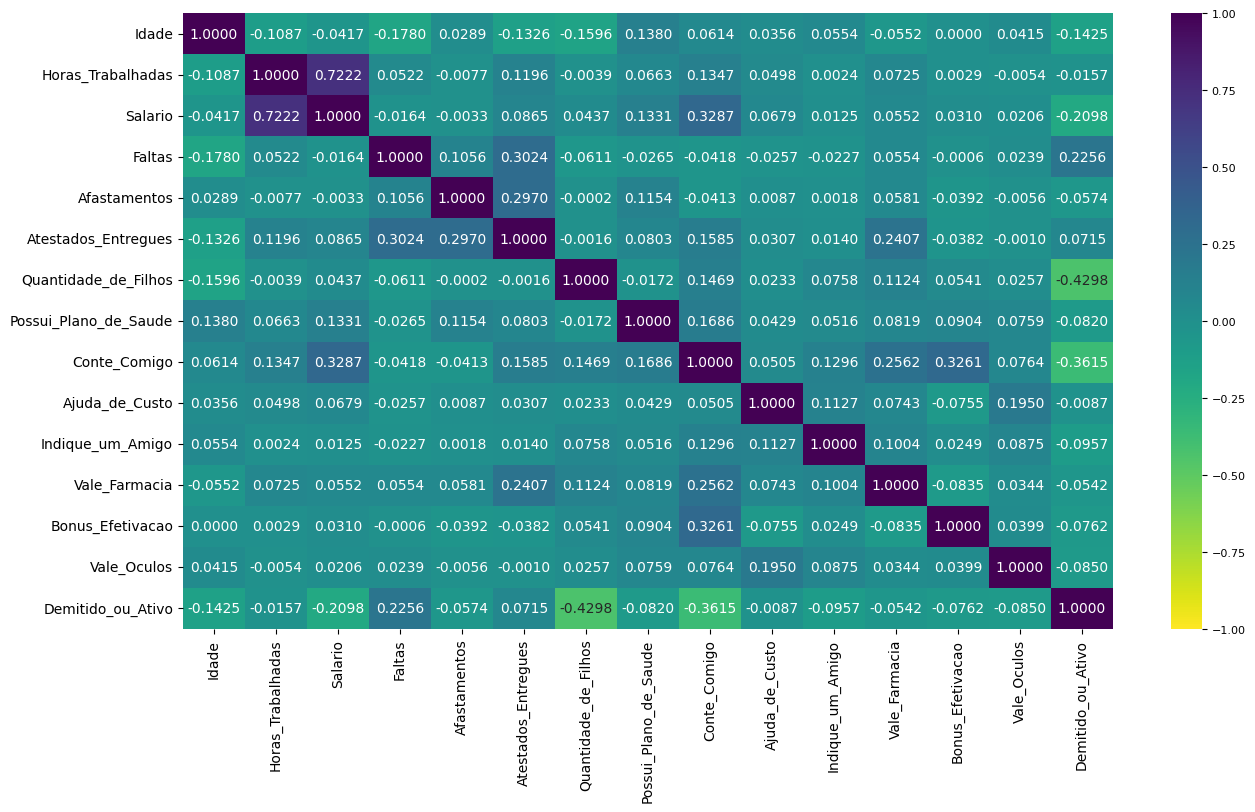

In [ ]:
correlation_matrix = df_corr_pearson.corr()
correlation_matrix

# Mapa de calor com as correlações entre todas as variáveis quantitativas
plt.figure(figsize=(15, 8))
heatmap = sns.heatmap(correlation_matrix, annot=True, fmt=".4f",
                      cmap=plt.cm.viridis_r,
                      annot_kws={'size': 10}, vmin=-1, vmax=1)
heatmap.set_xticklabels(heatmap.get_xticklabels(), fontsize=10)
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize=10)
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)
plt.show()



Variance Inflation Factor

In [ ]:
# Calculando os valores de VIF
X1 = sm.add_constant(df[['Idade', 'Salario','Horas_Trabalhadas',
                         'Faltas','Afastamentos','Atestados_Entregues',
                         'Quantidade_de_Filhos','Possui_Plano_de_Saude',
                         'Conte_Comigo','Ajuda_de_Custo','Indique_um_Amigo',
                         'Vale_Farmacia','Bonus_Efetivacao','Vale_Oculos',]])
VIF = pd.DataFrame()
VIF["Variável"] = X1.columns[1:]
VIF["VIF"] = [variance_inflation_factor(X1.values, i+1)
              for i in range(X1.shape[1]-1)]

# Calculando as Tolerâncias
VIF["Tolerância"] = 1 / VIF["VIF"]
VIF

,Variável,VIF,Tolerância
0,Idade,1.129618,0.885255
1,Salario,2.433868,0.410869
2,Horas_Trabalhadas,2.214952,0.451477
3,Faltas,1.148205,0.870924
4,Afastamentos,1.129600,0.885269
5,Atestados_Entregues,1.324310,0.755110
6,Quantidade_de_Filhos,1.077324,0.928226
7,Possui_Plano_de_Saude,1.085585,0.921162
8,Conte_Comigo,1.530457,0.653400
9,Ajuda_de_Custo,1.067870,0.936443


PairPlot

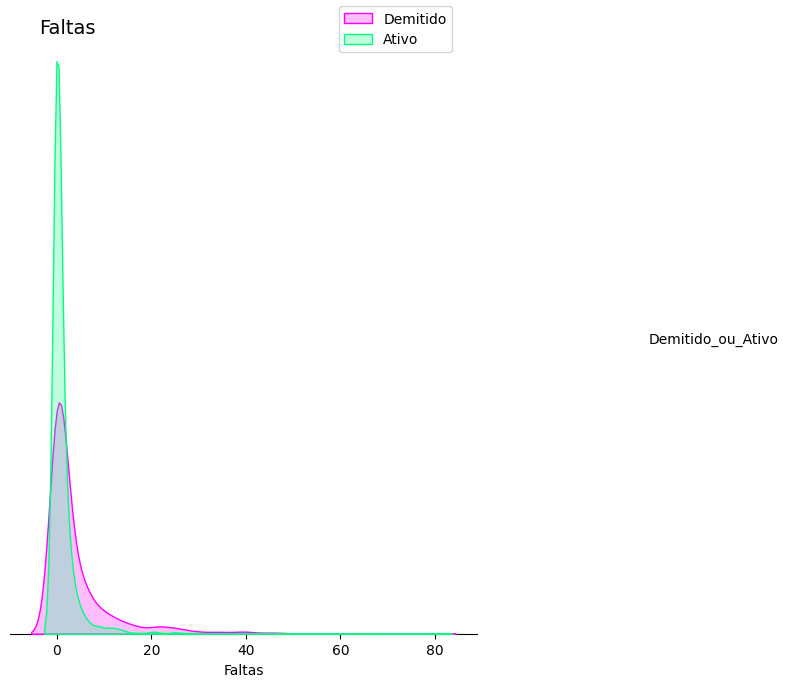

In [ ]:
cores_desejadas = {0: 'springgreen', 1: 'magenta'}

g = sns.pairplot(df[['Demitido_ou_Ativo','Faltas']],
                 hue='Demitido_ou_Ativo',
                 corner=True,
                 markers=["o", "s"],
                 palette=cores_desejadas)
g.fig.set_size_inches(8, 8)
g.fig.suptitle('Faltas', fontsize=14, x= 0.1, y= 0.98)
g.fig.legend(labels=['Demitido', 'Ativo'], loc='upper center')
plt.show()

Dummização

In [ ]:
df_dummies = pd.get_dummies(df,
                                       columns=['Segmento',
                                                'Estado_Civil',
                                                'Horas_Trabalhadas',
                                                'Etnia',
                                                'Genero',
                                                'Geracao',
                                                'Grau_de_Instrucao'
                                                ],
                                       dtype=int,
                                       drop_first=True)

In [ ]:
df_dummies.info()

In [ ]:
lista_colunas = list(df_dummies.drop(columns=['Demitido_ou_Ativo']).columns)
formula_dummies_modelo = ' + '.join(lista_colunas)
formula_dummies_modelo = "Demitido_ou_Ativo ~ " + formula_dummies_modelo
print("Fórmula utilizada: ",formula_dummies_modelo)

# Modelo propriamente dito
df_modelo = sm.Logit.from_formula(formula_dummies_modelo,
                                               df_dummies).fit()


Fórmula utilizada:  Demitido_ou_Ativo ~ Faltas + Salario + Idade + Afastamentos + Atestados_Entregues + Quantidade_de_Filhos + Possui_Plano_de_Saude + Conte_Comigo + Ajuda_de_Custo + Indique_um_Amigo + Vale_Farmacia + Bonus_Efetivacao + Vale_Oculos + Segmento_Cds + Segmento_Central + Segmento_Empresas_Privadas + Segmento_Escolas_Privadas + Segmento_Escolas_Publicas + Segmento_Facilities + Segmento_Hospitais + Segmento_Lanchonete + Estado_Civil_Divorciado + Estado_Civil_Separado + Estado_Civil_Solteiro + Estado_Civil_Uniao_Estavel + Estado_Civil_Viuvo + Horas_Trabalhadas_60 + Horas_Trabalhadas_100 + Horas_Trabalhadas_110 + Horas_Trabalhadas_120 + Horas_Trabalhadas_125 + Horas_Trabalhadas_132 + Horas_Trabalhadas_150 + Horas_Trabalhadas_160 + Horas_Trabalhadas_180 + Horas_Trabalhadas_220 + Etnia_Branco + Etnia_Indigena + Etnia_Mulato + Etnia_Pardo + Etnia_Preto + Genero_Masculino + Geracao_Geracao_X + Geracao_Geracao_Y + Geracao_Geracao_Z + Grau_de_Instrucao_2_Grau_Completo + Grau_de_Inst

Stepwise

In [ ]:
#Estimação do modelo por meio do procedimento Stepwise
step_modelo = stepwise(df_modelo, pvalue_limit=0.05)

df['phat'] = step_modelo.predict()

Regression type: Logit 

Estimating model...: 
 Demitido_ou_Ativo ~ Q('Faltas') + Q('Salario') + Q('Idade') + Q('Afastamentos') + Q('Atestados_Entregues') + Q('Quantidade_de_Filhos') + Q('Possui_Plano_de_Saude') + Q('Conte_Comigo') + Q('Ajuda_de_Custo') + Q('Indique_um_Amigo') + Q('Vale_Farmacia') + Q('Bonus_Efetivacao') + Q('Vale_Oculos') + Q('Segmento_Cds') + Q('Segmento_Central') + Q('Segmento_Empresas_Privadas') + Q('Segmento_Escolas_Privadas') + Q('Segmento_Escolas_Publicas') + Q('Segmento_Facilities') + Q('Segmento_Hospitais') + Q('Segmento_Lanchonete') + Q('Estado_Civil_Divorciado') + Q('Estado_Civil_Separado') + Q('Estado_Civil_Solteiro') + Q('Estado_Civil_Uniao_Estavel') + Q('Estado_Civil_Viuvo') + Q('Horas_Trabalhadas_60') + Q('Horas_Trabalhadas_100') + Q('Horas_Trabalhadas_110') + Q('Horas_Trabalhadas_120') + Q('Horas_Trabalhadas_125') + Q('Horas_Trabalhadas_132') + Q('Horas_Trabalhadas_150') + Q('Horas_Trabalhadas_160') + Q('Horas_Trabalhadas_180') + Q('Horas_Trabalhadas_22

In [ ]:
step_modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:      Demitido_ou_Ativo   No. Observations:                 3475
Model:                          Logit   Df Residuals:                     3449
Method:                           MLE   Df Model:                           25
Date:                Mon, 01 Dec 2025   Pseudo R-squ.:                  0.4431
Time:                        20:58:53   Log-Likelihood:                -1340.5
converged:                       True   LL-Null:                       -2407.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
=================================================================================================================
                                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
Intercept                                         3.4182      0.427      8.005      0.000       2.581       4.255
Q('Faltas')                                       0.1147      0.014      8.026      0.000       0.087       0.143
Q('Salario')                                     -0.0011      0.000     -6.843      0.000      -0.001      -0.001
Q('Idade')                                       -0.0454      0.007     -6.775      0.000      -0.059      -0.032
Q('Afastamentos')                                -1.1553      0.153     -7.569      0.000      -1.455      -0.856
Q('Atestados_Entregues')                          0.0543      0.015      3.688      0.000       0.025       0.083
Q('Quantidade_de_Filhos')                        -5.9944      0.659     -9.101      0.000      -7.285      -4.704
Q('Conte_Comigo')                                -0.3315      0.019    -17.395      0.000      -0.369      -0.294
Q('Ajuda_de_Custo')                               0.2451      0.075      3.288      0.001       0.099       0.391
Q('Vale_Farmacia')                                0.0528      0.016      3.365      0.001       0.022       0.083
Q('Bonus_Efetivacao')                             0.7108      0.117      6.084      0.000       0.482       0.940
Q('Vale_Oculos')                                 -2.4363      0.853     -2.856      0.004      -4.108      -0.764
Q('Segmento_Central')                             1.2321      0.181      6.825      0.000       0.878       1.586
Q('Segmento_Empresas_Privadas')                   1.0196      0.140      7.297      0.000       0.746       1.293
Q('Segmento_Escolas_Privadas')                    0.6532      0.223      2.923      0.003       0.215       1.091
Q('Segmento_Hospitais')                           1.2791      0.254      5.038      0.000       0.781       1.777
Q('Segmento_Lanchonete')                          4.2127      1.729      2.436      0.015       0.824       7.602
Q('Estado_Civil_Uniao_Estavel')                  -1.0049      0.346     -2.903      0.004      -1.683      -0.326
Q('Horas_Trabalhadas_100')                       -1.9084      0.416     -4.586      0.000      -2.724      -1.093
Q('Etnia_Branco')                                 1.2306      0.199      6.197      0.000       0.841       1.620
Q('Etnia_Indigena')                               1.8876      0.834      2.262      0.024       0.252       3.523
Q('Etnia_Pardo')                                  1.4593      0.200      7.301      0.000       1.068       1.851
Q('Genero_Masculino')                            -0.4972      0.174     -2.865      0.004      -0.837      -0.157
Q('Geracao_Geracao_X')                           -0.3609      0.127     -2.844      0.004      -0.610      -0.112
Q('Geracao_Geracao_Z')                           -1.0647      0.177     -6.019      0.000      -1.411      -0.718
Q('Grau_de_Instrucao_5_a_8_Serie_Incompleta')    

In [ ]:
import statsmodels.api as sm
import numpy as np
import pandas as pd

def calculate_log_odds(model_results):
  """
  Calculates the log odds for each coefficient in a logistic regression model.

  Args:
    model_results: The results object from a statsmodels logistic regression model.

  Returns:
    A pandas Series containing the log odds for each coefficient.
  """
  return model_results.params

# Calculate and print the log odds using the step_modelo
log_odds = calculate_log_odds(step_modelo)

# Convert the log odds Series to a DataFrame for table display
log_odds_df = pd.DataFrame({'Variable': log_odds.index, 'Log Odds': log_odds.values})

# Calculate the odds ratios by exponentiating the log odds
log_odds_df['Odds Ratio'] = np.exp(log_odds_df['Log Odds'])

print("Log Odds and Odds Ratios:")
display(log_odds_df)

Log Odds and Odds Ratios:


,Variable,Log Odds,Odds Ratio
0,Intercept,3.418186,30.514000
1,Q('Faltas'),0.114743,1.121585
2,Q('Salario'),-0.001089,0.998911
3,Q('Idade'),-0.045388,0.955627
4,Q('Afastamentos'),-1.155342,0.314950
5,Q('Atestados_Entregues'),0.054312,1.055813
6,Q('Quantidade_de_Filhos'),-5.994374,0.002493
7,Q('Conte_Comigo'),-0.331526,0.717827
8,Q('Ajuda_de_Custo'),0.245117,1.277770
9,Q('Vale_Farmacia'),0.052762,1.054179


In [ ]:
df

In [ ]:
X = df_dummies.drop(columns=['Demitido_ou_Ativo'])
y = df_dummies['Demitido_ou_Ativo']

# Esse pacote precisa que a constante seja definida pelo usuário
X = sm.add_constant(X)

# Estimação do modelo - função 'MNLogit' ('statsmodels.discrete.discrete_model')
modelo_final = sm.Logit(y, X).fit()

loglik = modelo_final.llf
print(f"Log-Likelihood do modelo: {loglik:.4f}")

def Qui2(df):
    maximo = df.llf
    minimo = df.llnull
    qui2 = -2*(minimo - maximo)
    pvalue = stats.distributions.chi2.sf(qui2,1)
    df = pd.DataFrame({'Qui quadrado':[qui2],
                       'pvalue':[pvalue]})
    return df

# In[4.4]: Estatística geral do 'df'

Qui2(modelo_final)

         Current function value: 0.381233
         Iterations: 35
Log-Likelihood do modelo: -1324.7861


,Qui quadrado,pvalue
0,2165.092666,0.0


Variance Inflation Factor

In [ ]:
# Calculando os valores de VIF
X1 = sm.add_constant(df_dummies[['Faltas', 'Salario','Idade',
                         'Afastamentos','Atestados_Entregues','Quantidade_de_Filhos',
                         'Conte_Comigo','Ajuda_de_Custo',
                         'Vale_Farmacia','Bonus_Efetivacao','Vale_Oculos',
                         'Segmento_Central','Segmento_Empresas_Privadas','Segmento_Escolas_Publicas',
                         'Segmento_Hospitais','Segmento_Lanchonete','Estado_Civil_Uniao_Estavel',
                         'Horas_Trabalhadas_100','Horas_Trabalhadas_220','Etnia_Branco',
                         'Etnia_Pardo','Geracao_Geracao_Y','Grau_de_Instrucao_5_a_8_Serie_Incompleta']])
VIF = pd.DataFrame()
VIF["Variável"] = X1.columns[1:]
VIF["VIF"] = [variance_inflation_factor(X1.values, i+1)
              for i in range(X1.shape[1]-1)]

# Calculando as Tolerâncias
VIF["Tolerância"] = 1 / VIF["VIF"]
VIF

,Variável,VIF,Tolerância
0,Faltas,1.160628,0.861602
1,Salario,2.839869,0.352129
2,Idade,1.245728,0.802744
3,Afastamentos,1.123140,0.890361
4,Atestados_Entregues,1.357970,0.736393
5,Quantidade_de_Filhos,1.168579,0.855740
6,Conte_Comigo,1.604247,0.623345
7,Ajuda_de_Custo,1.080589,0.925421
8,Vale_Farmacia,1.227539,0.814638
9,Bonus_Efetivacao,1.237353,0.808177


Matriz de Confusão

In [ ]:
def matriz_confusao(predicts, observado, cutoff):

    values = predicts.values

    predicao_binaria = []

    for item in values:
        if item < cutoff:
            predicao_binaria.append(0)
        else:
            predicao_binaria.append(1)

    cm = confusion_matrix(predicao_binaria, observado)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.xlabel('True')
    plt.ylabel('Classified')
    plt.gca().invert_xaxis()
    plt.gca().invert_yaxis()
    plt.show()

    sensitividade = recall_score(observado, predicao_binaria, pos_label=1)
    especificidade = recall_score(observado, predicao_binaria, pos_label=0)
    acuracia = accuracy_score(observado, predicao_binaria)

    #Visualizando os principais indicadores desta matriz de confusão
    indicadores = pd.DataFrame({'Sensitividade':[sensitividade],
                                'Especificidade':[especificidade],
                                'Acurácia':[acuracia]})
    return indicadores


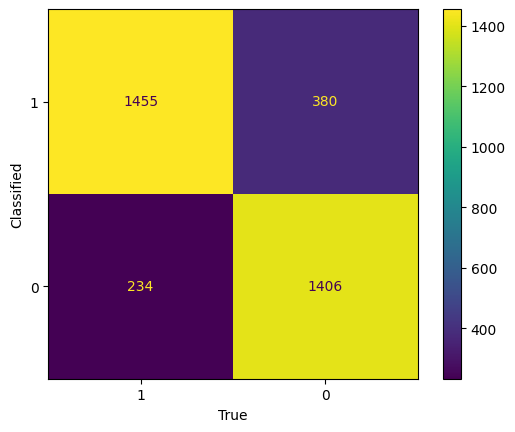

,Sensitividade,Especificidade,Acurácia
0,0.861456,0.787234,0.823309


In [ ]:
df_dummies['phat'] = step_modelo.predict()

# Matriz de confusão para cutoff = 0.5
matriz_confusao(observado=df_dummies['Demitido_ou_Ativo'],
                predicts=df_dummies['phat'],
                cutoff=0.50)

Avaliação do melhor valor de sensitividade e especificidade

In [ ]:
def espec_sens(observado,predicts):

    # adicionar objeto com os valores dos predicts
    values = predicts.values

    # range dos cutoffs a serem analisados em steps de 0.01
    cutoffs = np.arange(0,1.01,0.01)

    # Listas que receberão os resultados de especificidade e sensitividade
    lista_sensitividade = []
    lista_especificidade = []

    for cutoff in cutoffs:

        predicao_binaria = []

        # Definindo resultado binário de acordo com o predict
        for item in values:
            if item >= cutoff:
                predicao_binaria.append(1)
            else:
                predicao_binaria.append(0)

        # Cálculo da sensitividade e especificidade no cutoff
        sensitividade = recall_score(observado, predicao_binaria, pos_label=1)
        especificidadee = recall_score(observado, predicao_binaria, pos_label=0)

        # Adicionar valores nas listas
        lista_sensitividade.append(sensitividade)
        lista_especificidade.append(especificidadee)

    # Criar dataframe com os resultados nos seus respectivos cutoffs
    resultado = pd.DataFrame({'cutoffs':cutoffs,'sensitividade':lista_sensitividade,'especificidade':lista_especificidade})
    return resultado


In [ ]:

dados_plotagem = espec_sens(observado = df_dummies['Demitido_ou_Ativo'],
                            predicts = df_dummies['phat'])
dados_plotagem


,cutoffs,sensitividade,especificidade
0,0.00,1.000000,0.000000
1,0.01,0.998224,0.364502
2,0.02,0.997040,0.390817
3,0.03,0.995263,0.402576
4,0.04,0.994079,0.410414
...,...,...,...
96,0.96,0.095915,0.996641
97,0.97,0.077561,0.997200
98,0.98,0.050326,0.998880
99,0.99,0.030195,1.000000


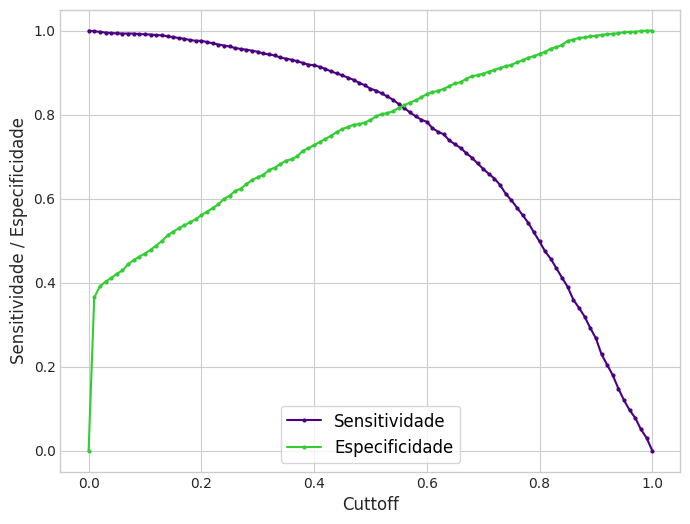

In [ ]:

plt.figure(figsize=(8,6))
with plt.style.context('seaborn-v0_8-whitegrid'):
    plt.plot(dados_plotagem.cutoffs,dados_plotagem.sensitividade, marker='o',
         color='indigo', markersize=2)
    plt.plot(dados_plotagem.cutoffs,dados_plotagem.especificidade, marker='o',
         color='limegreen', markersize=2)
plt.xlabel('Cuttoff', fontsize=12)
plt.ylabel('Sensitividade / Especificidade', fontsize=12)
plt.xticks(np.arange(0, 1.1, 0.2), fontsize=10)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=10)
plt.legend(['Sensitividade', 'Especificidade'], fontsize=12)
plt.show()


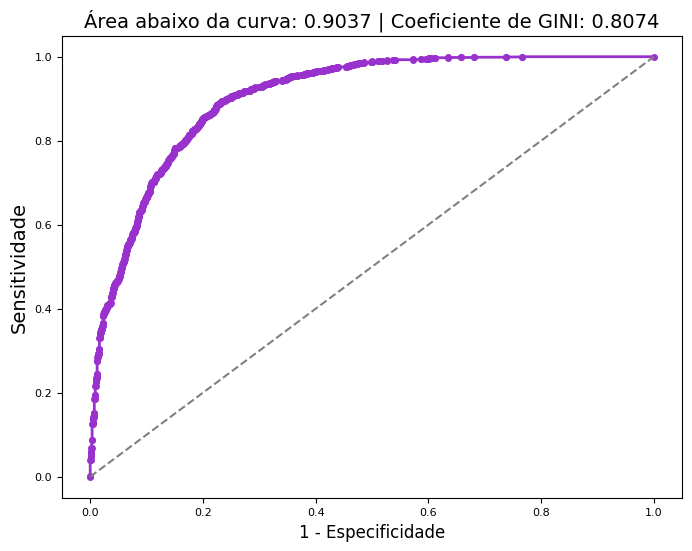

In [ ]:
from sklearn.metrics import roc_curve, auc

# Função 'roc_curve' do pacote 'metrics' do sklearn

fpr, tpr, thresholds =roc_curve(df_dummies['Demitido_ou_Ativo'],
                                df_dummies['phat'])
roc_auc = auc(fpr, tpr)

# Cálculo do coeficiente de GINI
gini = (roc_auc - 0.5)/(0.5)

# Plotando a curva ROC
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, marker='o', color='darkorchid', markersize=4, linewidth=2)
plt.plot(fpr, fpr, color='gray', linestyle='dashed')
plt.title('Área abaixo da curva: %g' % round(roc_auc, 4) +
          ' | Coeficiente de GINI: %g' % round(gini, 4), fontsize=14)
plt.xlabel('1 - Especificidade', fontsize=12)
plt.ylabel('Sensitividade', fontsize=14)
plt.xticks(np.arange(0, 1.1, 0.2), fontsize=8)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=8)
plt.show()


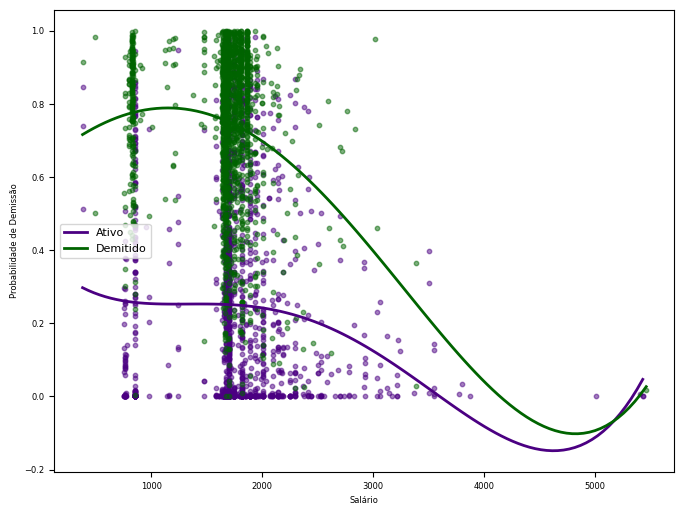

In [ ]:
# In[4.10]: Plotagens das probabilidades

# Plotagem das smooth probability lines para a variável 'Demitido_ou_Ativo'

# 0: Ativo
# 1: Demitido

plt.figure(figsize=(8,6))

# Plot para "Ativo"
sns.regplot(x='Salario', y=df_dummies[df_dummies['Demitido_ou_Ativo'] == 0]['phat'],
            data=df_dummies[df_dummies['Demitido_ou_Ativo'] == 0], ci=False, order=4,
            line_kws={'color':'indigo', 'linewidth':2,
                      'label':'Ativo'},
            scatter_kws={'color':'indigo', 's':10, 'alpha':0.5})

# Plot para "Demitido"
sns.regplot(x='Salario', y=df_dummies[df_dummies['Demitido_ou_Ativo'] == 1]['phat'],
            data=df_dummies[df_dummies['Demitido_ou_Ativo'] == 1], ci=None, order=4,
            line_kws={'color':'darkgreen', 'linewidth':2,
                      'label':'Demitido'},
            scatter_kws={'color':'darkgreen', 's':10, 'alpha':0.5})

plt.xlabel('Salário', fontsize=6)
plt.ylabel('Probabilidade de Demissão', fontsize=6)
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.legend(loc='center left', fontsize=8)
plt.show()